Importing the Dependencies

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn.datasets
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn import metrics

Importing the Boston House Price Dataset

In [8]:
house_price_dataframe = pd.read_csv("BostonHousing.csv")

house_price_dataframe.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,price
0,0.00632,18,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4


In [10]:
print(house_price_dataframe)

      crim  zn  indus  chas    nox     rm   age     dis  rad  tax  ptratio  \
0  0.00632  18   2.31     0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0   7.07     0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0   7.07     0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0   2.18     0  0.458  6.998  45.8  6.0622    3  222     18.7   

        b  lstat  price  
0  396.90   4.98   24.0  
1  396.90   9.14   21.6  
2  392.83   4.03   34.7  
3  394.63   2.94   33.4  


In [14]:
house_price_dataframe.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,price
0,0.00632,18,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4


In [16]:
# Print First 5 rows of our DataFrame
house_price_dataframe.head()
house_price_dataframe.info()
house_price_dataframe.describe()

<class 'pandas.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     4 non-null      float64
 1   zn       4 non-null      int64  
 2   indus    4 non-null      float64
 3   chas     4 non-null      int64  
 4   nox      4 non-null      float64
 5   rm       4 non-null      float64
 6   age      4 non-null      float64
 7   dis      4 non-null      float64
 8   rad      4 non-null      int64  
 9   tax      4 non-null      int64  
 10  ptratio  4 non-null      float64
 11  b        4 non-null      float64
 12  lstat    4 non-null      float64
 13  price    4 non-null      float64
dtypes: float64(10), int64(4)
memory usage: 580.0 bytes


,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,price
count,4.000000,4.0,4.000000,4.0,4.000000,4.000000,4.000000,4.000000,4.000000,4.00000,4.000000,4.000000,4.000000,4.000000
mean,0.023323,4.5,4.657500,0.0,0.483500,6.794750,62.750000,5.021600,2.000000,250.50000,17.400000,395.315000,5.272500,28.425000
std,0.011584,9.0,2.786221,0.0,0.036701,0.356644,13.624121,0.807603,0.816497,31.76476,1.462874,1.972215,2.709703,6.590081
min,0.006320,0.0,2.180000,0.0,0.458000,6.421000,45.800000,4.090000,1.000000,222.00000,15.300000,392.830000,2.940000,21.600000
25%,0.022047,0.0,2.277500,0.0,0.466250,6.536500,57.275000,4.747825,1.750000,237.00000,17.175000,394.180000,3.757500,23.400000
50%,0.027300,0.0,4.690000,0.0,0.469000,6.786500,63.150000,4.967100,2.000000,242.00000,17.800000,395.765000,4.505000,28.700000
75%,0.028575,4.5,7.070000,0.0,0.486250,7.044750,68.625000,5.240875,2.250000,255.50000,18.025000,396.900000,6.020000,33.725000
max,0.032370,18.0,7.070000,0.0,0.538000,7.185000,78.900000,6.062200,3.000000,296.00000,18.700000,396.900000,9.140000,34.700000


In [19]:
print(house_price_dataframe.columns)

Index(['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax',
       'ptratio', 'b', 'lstat', 'price'],
      dtype='str')


In [20]:
house_price_dataframe.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,price
0,0.00632,18,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4


In [21]:
# checking the number of rows and Columns in the data frame
house_price_dataframe.shape

(4, 14)

In [22]:
# check for missing values
house_price_dataframe.isnull().sum()

crim       0
zn         0
indus      0
chas       0
nox        0
rm         0
age        0
dis        0
rad        0
tax        0
ptratio    0
b          0
lstat      0
price      0
dtype: int64

In [23]:
# statistical measures of the dataset
house_price_dataframe.describe()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,price
count,4.000000,4.0,4.000000,4.0,4.000000,4.000000,4.000000,4.000000,4.000000,4.00000,4.000000,4.000000,4.000000,4.000000
mean,0.023323,4.5,4.657500,0.0,0.483500,6.794750,62.750000,5.021600,2.000000,250.50000,17.400000,395.315000,5.272500,28.425000
std,0.011584,9.0,2.786221,0.0,0.036701,0.356644,13.624121,0.807603,0.816497,31.76476,1.462874,1.972215,2.709703,6.590081
min,0.006320,0.0,2.180000,0.0,0.458000,6.421000,45.800000,4.090000,1.000000,222.00000,15.300000,392.830000,2.940000,21.600000
25%,0.022047,0.0,2.277500,0.0,0.466250,6.536500,57.275000,4.747825,1.750000,237.00000,17.175000,394.180000,3.757500,23.400000
50%,0.027300,0.0,4.690000,0.0,0.469000,6.786500,63.150000,4.967100,2.000000,242.00000,17.800000,395.765000,4.505000,28.700000
75%,0.028575,4.5,7.070000,0.0,0.486250,7.044750,68.625000,5.240875,2.250000,255.50000,18.025000,396.900000,6.020000,33.725000
max,0.032370,18.0,7.070000,0.0,0.538000,7.185000,78.900000,6.062200,3.000000,296.00000,18.700000,396.900000,9.140000,34.700000


Understanding the correlation between various features in the dataset

1. Positive Correlation

2. Negative Correlation

In [24]:
correlation = house_price_dataframe.corr()

<Axes: >

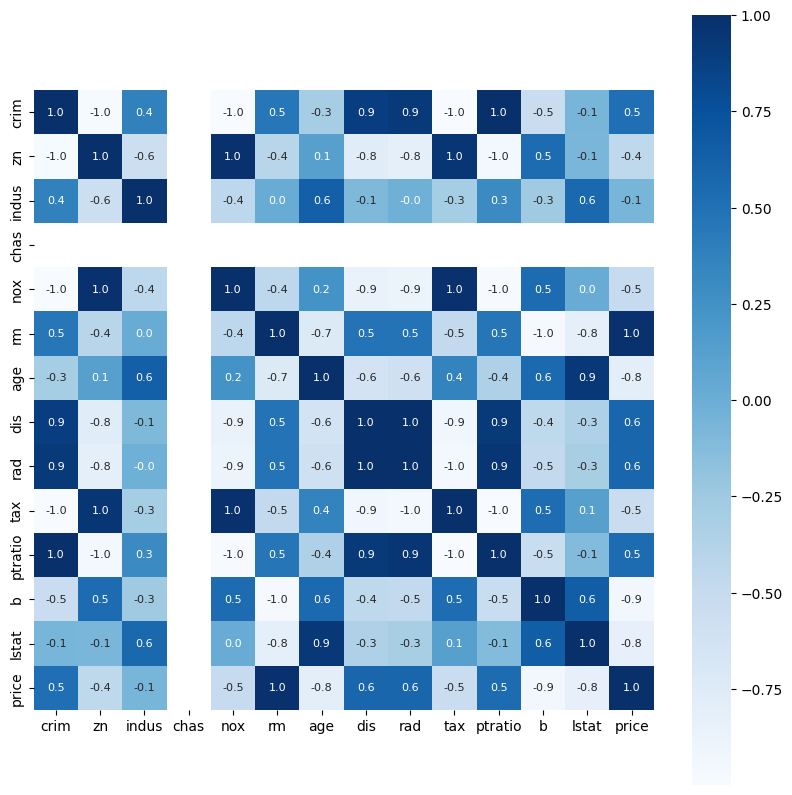

In [25]:
# constructing a heatmap to nderstand the correlation
plt.figure(figsize=(10,10))
sns.heatmap(correlation, cbar=True, square=True, fmt='.1f', annot=True, annot_kws={'size':8}, cmap='Blues')

Splitting the data and Target

In [26]:
X = house_price_dataframe.drop(['price'], axis=1)
Y = house_price_dataframe['price']

In [27]:
print(X)
print(Y)

      crim  zn  indus  chas    nox     rm   age     dis  rad  tax  ptratio  \
0  0.00632  18   2.31     0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0   7.07     0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0   7.07     0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0   2.18     0  0.458  6.998  45.8  6.0622    3  222     18.7   

        b  lstat  
0  396.90   4.98  
1  396.90   9.14  
2  392.83   4.03  
3  394.63   2.94  
0    24.0
1    21.6
2    34.7
3    33.4
Name: price, dtype: float64


Splitting the data into Training data and Test data

In [28]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, random_state = 2)

In [29]:
print(X.shape, X_train.shape, X_test.shape)

(4, 13) (3, 13) (1, 13)


Model Training

XGBoost Regressor

In [30]:
# loading the model
model = XGBRegressor()

In [31]:
# training the model with X_train
model.fit(X_train, Y_train)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


Evaluation

Prediction on training data

In [32]:
# accuracy for prediction on training data
training_data_prediction = model.predict(X_train)

In [33]:
print(training_data_prediction)

[33.39901  21.600945 24.000038]


In [34]:
# R squared error
score_1 = metrics.r2_score(Y_train, training_data_prediction)

# Mean Absolute Error
score_2 = metrics.mean_absolute_error(Y_train, training_data_prediction)

print("R squared error : ", score_1)
print('Mean Absolute Error : ', score_2)

R squared error :  0.9999999759051712
Mean Absolute Error :  0.0006576538085928026


Visualizing the actual Prices and predicted prices

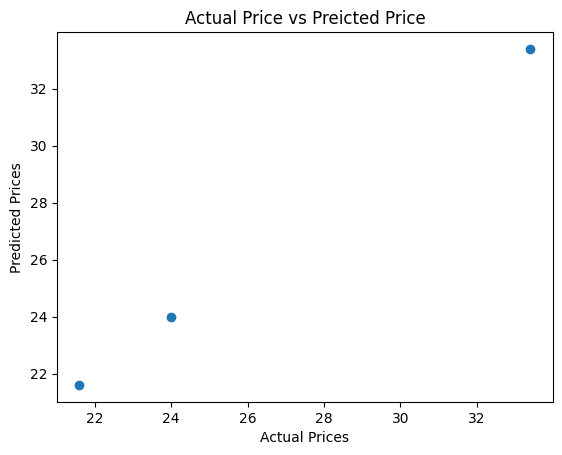

In [35]:
plt.scatter(Y_train, training_data_prediction)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual Price vs Preicted Price")
plt.show()

Prediction on Test Data

In [36]:
# accuracy for prediction on test data
test_data_prediction = model.predict(X_test)

In [37]:
# R squared error
score_1 = metrics.r2_score(Y_test, test_data_prediction)

# Mean Absolute Error
score_2 = metrics.mean_absolute_error(Y_test, test_data_prediction)

print("R squared error : ", score_1)
print('Mean Absolute Error : ', score_2)

R squared error :  nan
Mean Absolute Error :  10.701270294189456


c:\Users\pc\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_regression.py:1295: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
